## Title - Credit Scoring Model using Logistic Regression


## Description 
#### The Credit Scoring Model is a machine learning project designed to predict the creditworthiness of loan applicants based on their financial and demographic information. By analyzing historical customer data such as income, employment status, loan amount, credit history, debt ratio, repayment behavior, and other relevant features, the model classifies applicants into different credit risk categories.

#### The project follows a complete end-to-end machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, hyperparameter tuning, and performance evaluation.Using classification algorithm Logistic Regression is implemented and compared to identify the most accurate and reliable model.

#### The objective is to assist banks, financial institutions, and lending organizations in making data-driven loan approval decisions, reducing default risk, and improving the efficiency and consistency of credit evaluation.

### Installing the Dependences

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from sklearn.model_selection import train_test_split

### Downloading Dataset

In [2]:
credit_data=pd.read_csv('Dataset/Credit.csv')
credit_data

,income,loan_amount,term,credit_history,defaulted
0,60940.854754,17402.715471,60,1.0,1
1,49511.242579,6664.626123,36,0.0,0
2,63658.393686,17985.281393,60,0.0,1
3,79414.537415,21001.173770,36,1.0,0
4,47785.239255,4037.586145,36,1.0,0
...,...,...,...,...,...
1243,33734.378848,11861.633356,60,1.0,0
1244,40313.004189,13041.263066,60,NaN,0
1245,29969.075198,24661.792021,36,1.0,0
1246,52613.502429,8460.958634,60,0.0,0


In [3]:
credit_data.head()

,income,loan_amount,term,credit_history,defaulted
0,60940.854754,17402.715471,60,1.0,1
1,49511.242579,6664.626123,36,0.0,0
2,63658.393686,17985.281393,60,0.0,1
3,79414.537415,21001.173770,36,1.0,0
4,47785.239255,4037.586145,36,1.0,0


### Data type and shape of the dataset

In [4]:
credit_data.dtypes

income            float64
loan_amount       float64
term                int64
credit_history    float64
defaulted           int64
dtype: object

In [5]:
credit_data.shape

(1248, 5)

#### Preprocessing data

In [6]:
# Checking for Null Values
credit_data.isnull().sum()

income            120
loan_amount       122
term                0
credit_history    112
defaulted           0
dtype: int64

In [7]:
# Filling the null value by Mean or Median
credit_data.fillna({'income':credit_data['income'].median()}, inplace=True)
credit_data.fillna({'loan_amount':credit_data['loan_amount'].median()}, inplace=True)

In [8]:
credit_data.fillna({'credit_history':credit_data['credit_history'].mode()[0]}, inplace=True)

In [9]:
# Rechecking the null values

credit_data.isnull().sum()

income            0
loan_amount       0
term              0
credit_history    0
defaulted         0
dtype: int64

In [10]:
credit_data.describe()

,income,loan_amount,term,credit_history,defaulted
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000
mean,52500.945298,16167.787505,48.000000,0.771635,0.414263
std,16967.161028,5541.521139,12.004811,0.419948,0.492792
min,8000.000000,1000.000000,36.000000,0.000000,0.000000
25%,41673.912889,12772.722413,36.000000,1.000000,0.000000
50%,52462.564119,16052.247335,48.000000,1.000000,0.000000
75%,62987.634437,19610.211517,60.000000,1.000000,1.000000
max,121349.166832,35158.645407,60.000000,1.000000,1.000000


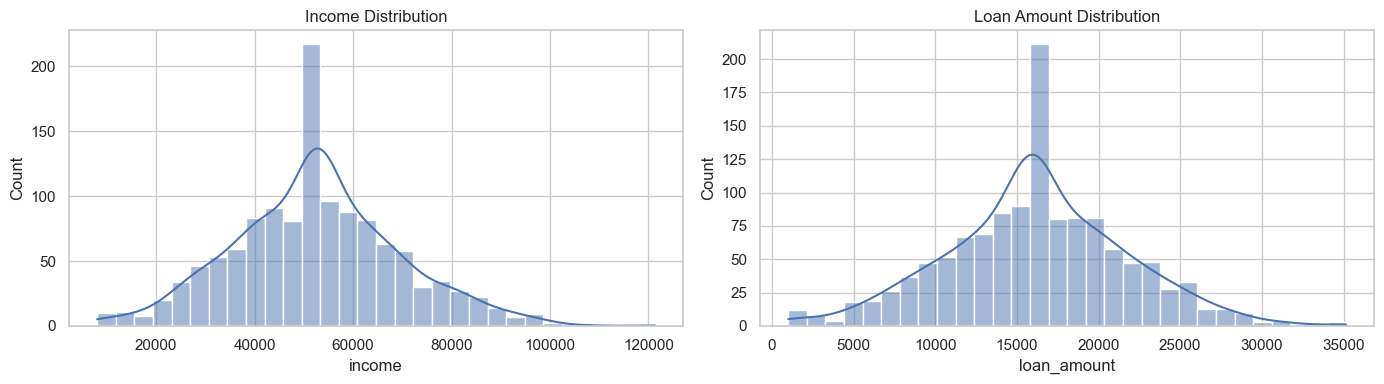

In [11]:
# Data Visulation
sns.set(style="whitegrid")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(credit_data['income'], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Income Distribution")

sns.histplot(credit_data['loan_amount'], kde=True, bins=30, ax=axes[1])
axes[1].set_title("Loan Amount Distribution")

plt.tight_layout()
plt.show()

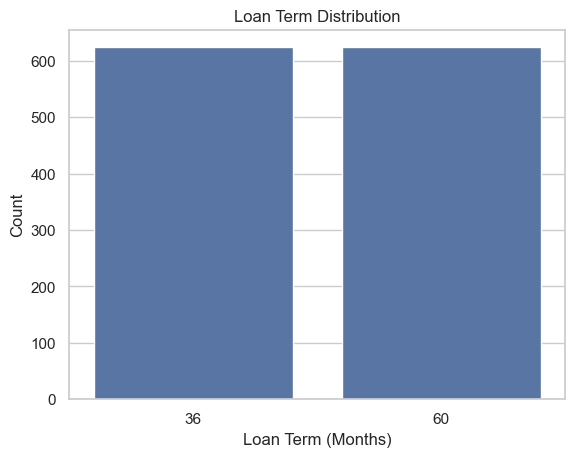

In [12]:

sns.countplot(x='term', data=credit_data)
plt.title("Loan Term Distribution")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Count")
plt.show()

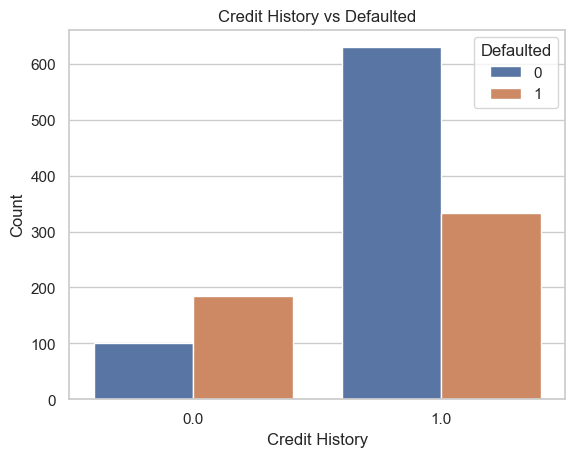

In [13]:

sns.countplot(x='credit_history', hue='defaulted', data=credit_data)
plt.title("Credit History vs Defaulted")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.legend(title='Defaulted')
plt.show()

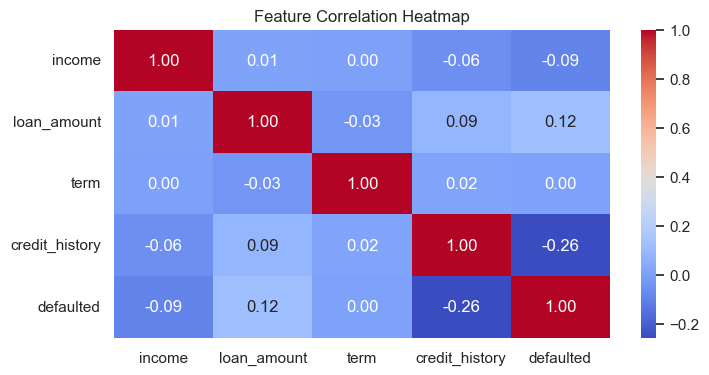

In [14]:

plt.figure(figsize=(8, 4))
sns.heatmap(credit_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

#### Feature Enginnnering


In [15]:
credit_data['term_binary'] = credit_data['term'].apply(lambda x: 1 if x == 60 else 0)

In [16]:
credit_data['log_income'] = np.log1p(credit_data['income'])
credit_data['log_loan_amount'] = np.log1p(credit_data['loan_amount'])

In [17]:
credit_data.columns

Index(['income', 'loan_amount', 'term', 'credit_history', 'defaulted',
       'term_binary', 'log_income', 'log_loan_amount'],
      dtype='object')

In [18]:

features = ['log_income', 'log_loan_amount', 'term_binary', 'credit_history']
target = 'defaulted'

### Model Traning

### 1 ---> Bad Customer
### 0 ---> Good Customer

In [19]:
credit_data['defaulted'].value_counts()

defaulted
0    731
1    517
Name: count, dtype: int64

In [20]:
X = credit_data[features]
y = credit_data[target]

In [21]:
X


,log_income,log_loan_amount,term_binary,credit_history
0,11.017675,9.764439,1,1.0
1,10.809975,8.804719,0,0.0
2,11.061302,9.797365,1,0.0
3,11.282449,9.952381,0,1.0
4,10.774493,8.303650,0,1.0
...,...,...,...,...
1243,10.426302,9.381149,1,1.0
1244,10.604454,9.475950,1,1.0
1245,10.307955,10.113051,0,1.0
1246,10.870747,9.043336,1,0.0


In [22]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1243    0
1244    0
1245    0
1246    0
1247    1
Name: defaulted, Length: 1248, dtype: int64

### Splitting Data Into Training data & Test Data

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
print(X.shape, X_train.shape, X_test.shape)

(1248, 4) (998, 4) (250, 4)


### Model Training Using Logistic Regression

In [25]:
model= LogisticRegression(max_iter=1000, random_state=42)

In [26]:
model.fit(X_train,y_train)
print("Model Trained Sucessfully")

Model Trained Sucessfully


### Model Evaluation

### Accuracy Score

In [27]:
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,y_train)

In [28]:
print(" Accuracy score of the training data is ",training_data_accuracy)

 Accuracy score of the training data is  0.687374749498998


In [29]:
X_test_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,y_test)

In [30]:
print("Accuracy score of the test data is",test_data_accuracy)

Accuracy score of the test data is 0.668


In [31]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   income           1248 non-null   float64
 1   loan_amount      1248 non-null   float64
 2   term             1248 non-null   int64  
 3   credit_history   1248 non-null   float64
 4   defaulted        1248 non-null   int64  
 5   term_binary      1248 non-null   int64  
 6   log_income       1248 non-null   float64
 7   log_loan_amount  1248 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 78.1 KB


### Building The Predictive System

In [32]:
input_data = (60940.854754202184,17402.715470744486,60,1.0
)


# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Borrower has defaulted')
else:
  print('The Borrower has not defaulted')

[0]
The Borrower has defaulted


c:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### The Model has sucessfully Trained